# Human-in-the-Loop

The Human-in-the-Loop (HITL) pattern integrates human judgment into AI workflows. Agents handle routine cases autonomously, while high-risk actions are gated on explicit human approval.

## Implementation with Flyte v2 + the Agent harness

This refactor implements a real gate: the sensitive action — `issue_refund` — is a `@tool(requires_approval=True)`. When the agent decides to call it, the harness **pauses the run** via `flyteplugins-hitl` and waits for a human to approve or deny before the tool executes.

#### ADK vs Flyte v2 + Agent harness

| Aspect | ADK | Flyte v2 + `Agent` harness |
|--------|-----|----------------------------|
| **Escalation trigger** | `escalate_to_human` mock tool | `@tool(requires_approval=True)` — real pause-for-approval |
| **Approval transport** | Not shown | `flyteplugins-hitl` surfaces the request in the UI |
| **On denial** | N/A | Agent recovers and tries another approach |
| **Personalization** | `CallbackContext` injection | Customer context passed in the message |
| **Routine tools** | `troubleshoot_issue`, `create_ticket` | `@tool` functions — schema from type hints |
| **Secrets** | `os.environ` | `flyte.Secret` injected by cluster |

> **🧭 When to use this pattern — and how Flyte helps**
>
> Use human-in-the-loop where mistakes carry safety, ethical, or financial weight (healthcare, finance, autonomy), where nuance exceeds what the model handles reliably, or to capture high-quality human feedback. In Flyte, `@tool(requires_approval=True)` pauses the run via `flyteplugins-hitl` until a person approves or denies the gated action.

### 1. Install dependencies

In [21]:
!uv pip install flyte litellm flyteplugins-hitl

Using Python 3.12.12 environment at: /Users/davidmirror/code/agentic-patterns-on-v2/.venv
Audited 3 packages in 71ms


### Connect to a remote Union cluster

The `flyteplugins-hitl` functionality only works on a Union cluster. Make sure your local config.yaml points to a Union cluster:

```yaml
admin:
  endpoint: dns:///<your_union_endpoint>
image:
  builder: remote
task:
  domain: development
  org: <your_union_org>
  project: flytesnacks

```


### 2. Store your API key

In [ ]:
!flyte create secret ANTHROPIC_API_KEY --value sk-...

### 3. Import dependencies and configure the TaskEnvironment

In [ ]:

import json
import os
import uuid
from dataclasses import dataclass, field
from datetime import timedelta

import flyte
import flyte.report
import flyteplugins.hitl as hitl
from flyte.ai.agents import Agent, AgentResult, tool
from pydantic import BaseModel, Field
from typing import List

flyte.init(
    endpoint="<your-union-endpoint-url>",
    org="<your-union-org>",
    project="<your-project>",
    domain="development",
    image_builder="remote",
    auth_type="DeviceFlow",
)
_image = (
    flyte.Image.from_debian_base(name="hitl-agent", python_version=(3, 12))
    .with_pip_packages("litellm", "flyteplugins-hitl")
)

hitl_env = flyte.TaskEnvironment(
    name="hitl_agent",
    image=_image,
    resources=flyte.Resources(cpu="1", memory="1Gi"),
    secrets=[
        flyte.Secret(key="ANTHROPIC_API_KEY", as_env_var="ANTHROPIC_API_KEY"),
    ],
    # The approval gate runs in the plugin's own environment (`hitl-event-task-env`,
    # which serves the approval web form). Declaring it here bundles and registers it
    # with this run; without it the gated tool call fails with
    # "Environment 'hitl-event-task-env' not found in image cache."
    depends_on=[hitl.env],
)

### 4. Define the customer context

`CustomerContext` is a typed task input — the agent receives the customer's tier and history and personalizes accordingly. There is no `SupportResult(escalate=...)` flag anymore: escalation is no longer a return value to interpret, it's an approval gate on the sensitive tool.

In [ ]:
class CustomerContext(BaseModel):
    """Typed customer context passed to the support agent.

    Pydantic BaseModel, NOT a @dataclass: when run.outputs() reconstructs the task
    interface, Flyte rebuilds dataclasses from their JSON schema via make_dataclass, and
    `field(default_factory=list)` fields lose their default there -> "non-default argument
    follows default argument". BaseModel uses Flyte's pydantic transformer and round-trips
    cleanly through the guess-interface path.
    """
    name: str
    tier: str = "standard"           # "standard" | "premium" | "enterprise"
    recent_purchases: List[str] = Field(default_factory=list)
    support_history: List[str] = Field(default_factory=list)

### 5. Define the tools (one gated by human approval)

`troubleshoot_issue` and `create_ticket` are ordinary `@tool`s. `issue_refund` is the sensitive, irreversible action — marked `@tool(requires_approval=True)`, so the harness pauses for a human decision before it runs.

In [ ]:
@tool
def troubleshoot_issue(issue: str, device_type: str = "") -> str:
    """Diagnose a technical issue and return step-by-step troubleshooting instructions.

    Args:
        issue: Description of the technical issue.
        device_type: Type of device, e.g. 'laptop' or 'phone'.
    """
    return (
        f"Troubleshooting for '{issue}' ({device_type or 'device'}): "
        "1) restart the device, 2) update firmware, 3) check cables/connections."
    )


@tool
def create_ticket(issue_type: str, details: str) -> str:
    """Create a support ticket and return its ID.

    Args:
        issue_type: Category of the issue.
        details: Full issue description for the ticket.
    """
    return f"TICKET-{uuid.uuid4().hex[:8].upper()} created for {issue_type}."


@tool(requires_approval=True)
def issue_refund(order_id: str, amount_usd: float) -> str:
    """Issue a refund for an order. High-risk and irreversible — requires human approval.

    Args:
        order_id: The order to refund.
        amount_usd: Refund amount in US dollars.
    """
    return f"Refund of ${amount_usd:.2f} issued for order {order_id}."


def _esc(text: str) -> str:
    return text.replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;")


async def gated_approval(tool: "AgentTool", args: dict) -> bool:
    """Surface the pause AND a clickable approval-form link in the task's report, then wait.

    There is no "Paused" action phase â the run stays Running while `event.wait()` polls
    object storage for the human's response. We create the event FIRST so its `form_url`
    (served by the hitl-event-app) is available to embed right here; click it to approve/deny.
    """
    pretty_args = json.dumps(args, indent=2, default=str)

    # Create the event first so its form URL is available to show in the report.
    event = await hitl.new_event.aio(
        f"approve_{tool.name}_{uuid.uuid4().hex[:6]}",
        data_type=bool,
        scope="run",
        prompt=f"Approve tool call `{tool.name}`?

Arguments:
{pretty_args}",
    )

    await flyte.report.log.aio(
        "<div style='border:2px solid #d97706;background:#fffbeb;padding:12px;border-radius:8px'>"
        "<h2 style='margin:0;color:#b45309'>⏸ PAUSED — waiting for human approval</h2>"
        f"<p>The agent wants to call <code>{tool.name}</code> with:</p>"
        f"<pre>{_esc(pretty_args)}</pre>"
        f"<p><a href='{event.form_url}' target='_blank' "
        "style='display:inline-block;padding:8px 16px;background:#2563eb;color:#fff;"
        "border-radius:6px;text-decoration:none;font-weight:bold'>▶ Open approval form</a></p>"
        "<p style='font-size:0.9em;color:#555'>The run stays <b>Running</b> until you submit; "
        "you can also approve/deny from the <code>hitl-event-app</code> sub-action's Reports tab.</p>"
        "</div>"
    )
    await flyte.report.flush.aio()

    approved = await event.wait.aio()

    color, label = ("#15803d", "✅ APPROVED") if approved else ("#b91c1c", "🛑 DENIED")
    await flyte.report.log.aio(f"<h3 style='color:{color}'>{label} — {tool.name}</h3>")
    await flyte.report.flush.aio()
    return approved


support_bot = Agent(
    name="support",
    model="claude-haiku-4-5",
    instructions=(
        "You are a technical support specialist for an electronics company. Personalize using "
        "the customer context provided. Use troubleshoot_issue to diagnose problems and "
        "create_ticket to log unresolved ones. If the customer is clearly entitled to a refund "
        "(defective product, or troubleshooting failed for a premium/enterprise customer), call "
        "issue_refund — this pauses for human approval before executing. If approval is denied, "
        "apologize and create a ticket for manual follow-up instead."
    ),
    tools=[troubleshoot_issue, create_ticket, issue_refund],
    approval_callback=gated_approval,
    max_turns=10,
)

### 6. Define the support agent task

The task is thin: it packs the customer context into the message and runs the agent. When the agent calls `issue_refund`, the harness blocks the run on human approval — the escalation is enforced by the gate, not by an outer `if result.escalate` branch.

In [19]:
@hitl_env.task(
    retries=1,
    timeout=timedelta(minutes=10),
    cache=flyte.Cache(behavior="disable"),
    report=True,  # so gated_approval's "⏸ PAUSED" banner renders in the action's report tab
)
async def support_agent(issue: str, customer: CustomerContext) -> str:
    """Technical support agent with an approval-gated refund action."""
    context = (
        f"Customer: {customer.name} (tier: {customer.tier}). "
        f"Recent purchases: {', '.join(customer.recent_purchases) or 'none'}. "
        f"Past issues: {', '.join(customer.support_history) or 'none'}.\n\n"
        f"Issue: {issue}"
    )
    result: AgentResult = await support_bot.run.aio(context)
    return result.summary or result.error or ""

### 7. Run the approval gate in action

Three scenarios, each exercising a different path:

1. **Alice** (premium, new issue) — the agent troubleshoots; `issue_refund` is never called, so the run completes normally.
2. **Eve** (enterprise, troubleshooting exhausted, defective unit) — the agent calls `issue_refund`, which **pauses the run**. `run.wait()` blocks until you open the run in the Flyte UI and approve or deny the pending tool call.
3. **Bob** (standard, accidental water damage) — not "clearly entitled" per the agent's instructions, so it declines and creates a ticket — no gated call, no pause.

The gate only fires when the agent actually invokes the gated tool. If no scenario meets the refund criteria, nothing pauses — that's expected, not a broken gate.

In [ ]:
SCENARIOS = [
    # 1) ROUTINE — premium customer, brand-new issue. The agent troubleshoots first and
    #    does NOT call issue_refund, so the run completes without pausing.
    (
        "My laptop screen flickers and sometimes goes black.",
        CustomerContext(
            name="Alice", tier="premium",
            recent_purchases=["ThinkPad X1 Carbon"],
            support_history=[],
        ),
    ),
    # 2) APPROVAL GATE FIRES — enterprise customer, troubleshooting already exhausted, a
    #    clear manufacturing defect, and an explicit refund request with order id + amount.
    #    The agent calls issue_refund -> the run PAUSES for human approval in the Flyte UI.
    #    run.wait() below blocks until you approve or deny it.
    (
        "I've already done every step your support team gave me over the past two weeks — "
        "full restart, firmware update, reseating every cable — and my two-week-old ThinkPad "
        "still won't power on at all. This is a manufacturing defect, not user error. Please "
        "issue a refund of $1899 for order ORD-7788.",
        CustomerContext(
            name="Eve", tier="enterprise",
            recent_purchases=["ThinkPad X1 Carbon"],
            support_history=["Won't power on", "Escalated: dead unit"],
        ),
    ),
    # 3) POLICY BOUNDARY — standard tier, accidental water/physical damage (not a defect).
    #    The agent declines the refund and creates a ticket instead: no gated call, no pause.
    (
        "My phone is unresponsive after I dropped it in water. I want a refund for order ORD-9912.",
        CustomerContext(
            name="Bob", tier="standard",
            recent_purchases=["iPhone 15"],
            support_history=["Battery drain", "Screen crack"],
        ),
    ),
]

for issue, customer in SCENARIOS:
    run = flyte.run(support_agent, issue=issue, customer=customer)
    run.wait()  
    print(f"Customer: {customer.name} | Issue: {issue[:60]}")
    print(f"  -> {run.outputs()[0]}")
    print()

> Building 3 images...

> Building image hitl-agent for environment hitl_agent

> Building image hitl-event-app-image for environment hitl-event-task-env

> Building image hitl-event-app-image for environment hitl-event-app

✓ Built image for environment hitl_agent: 
356633062068.dkr.ecr.us-east-2.amazonaws.com/union/demo:hitl-agent-9dd5ed7dbd3a2e693a8bf1cd22c47e62

...

✓ Built image for environment hitl-event-task-env: 
356633062068.dkr.ecr.us-east-2.amazonaws.com/union/demo:hitl-event-app-image-10a803f410321bcb14704cc2e5351c59

✓ Built image for environment hitl-event-app: 
356633062068.dkr.ecr.us-east-2.amazonaws.com/union/demo:hitl-event-app-image-10a803f410321bcb14704cc2e5351c59

Output()

Run 'u9qb6ppxdps9qz8wbjf8' completed successfully.

Customer: Bob | Issue: My phone is unresponsive after I dropped it in water. I want
  -> Here are the troubleshooting steps for water damage on your iPhone 15:

1. **Restart the device** – Power it off completely and let it dry for at least 24-48 hours before attempting to power it back on
2. **Update firmware** – Once powered back on, check for any available iOS updates that might resolve unresponsiveness
3. **Check cables/connections** – Inspect the charging port and Lightning connector for any water residue or corrosion

**Important:** Given that your phone was submerged in water, please allow adequate drying time before attempting these steps, as premature power-on could cause further damage.

If after following these steps your iPhone 15 remains unresponsive, we can discuss a refund. As a standard-tier customer with a defective unit (water damage from accidental drop), you would likely be eligible. Please try the troubleshooting steps first, and let me know the results. If the dev

The execution shows the form is accesible from the task's `Reports` tab:

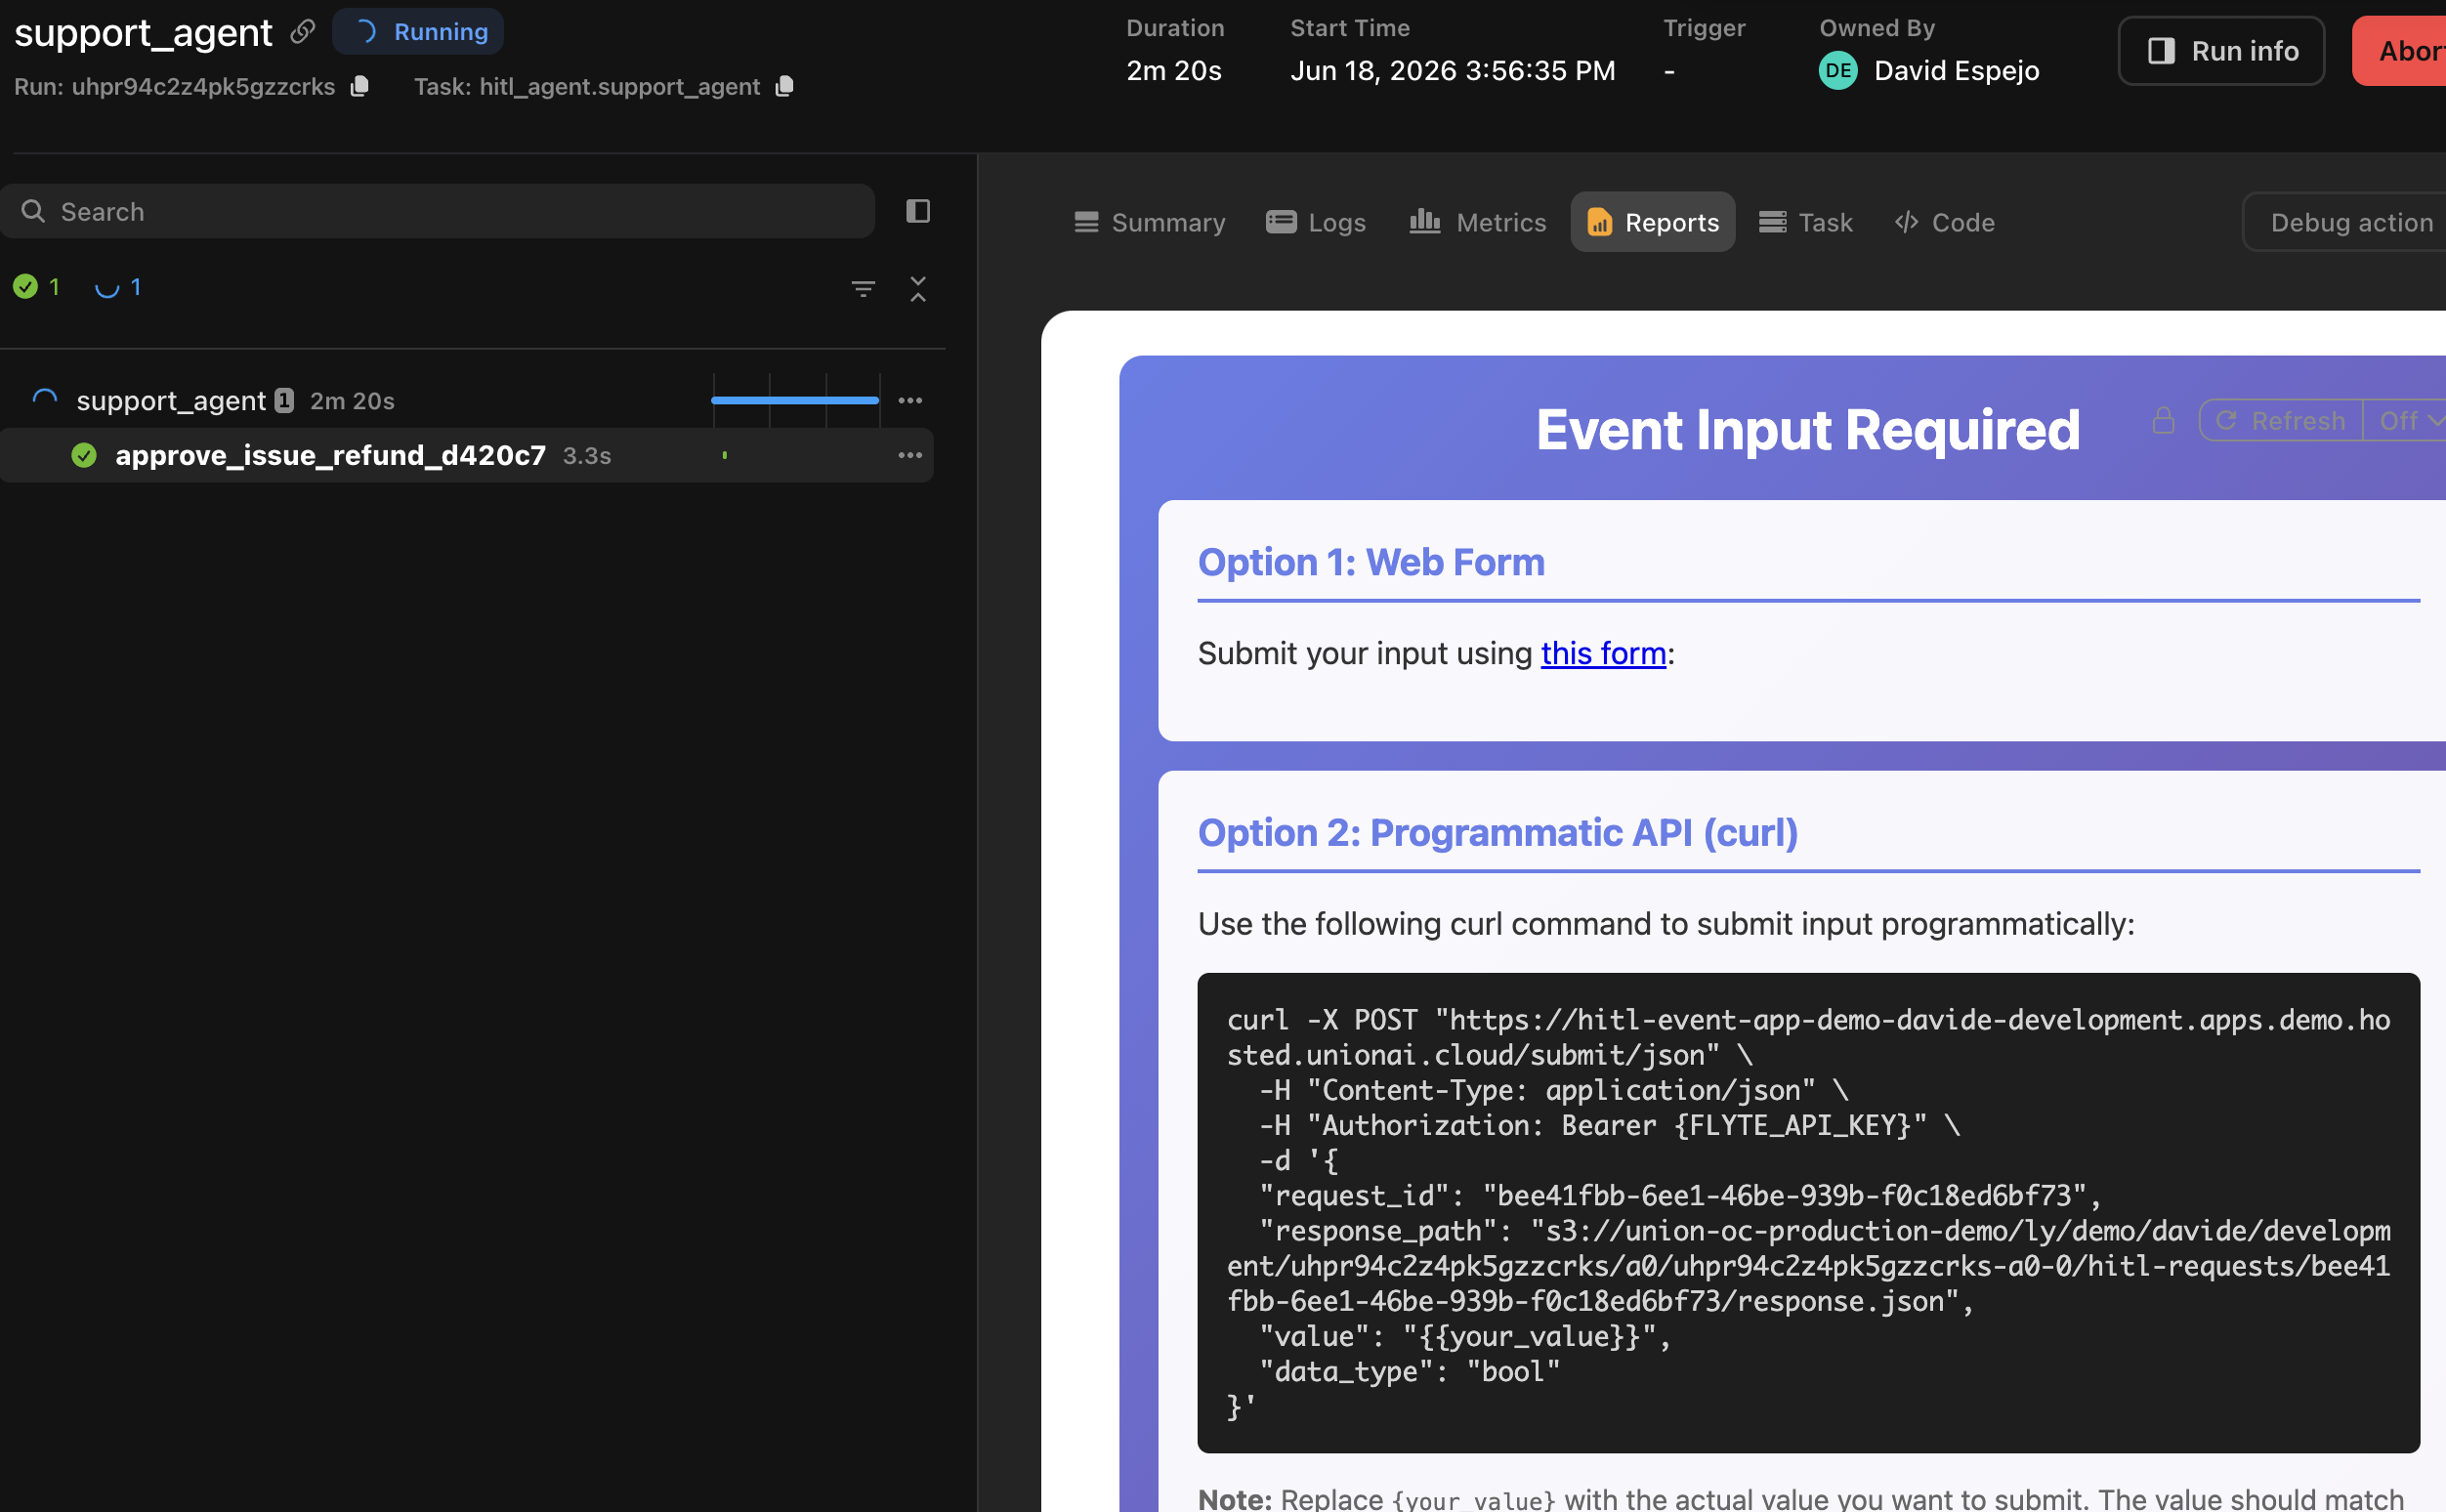

With the linked form enabling users to either approve or reject tool use. The execution remains Running but proceeds as soon as there's human input:

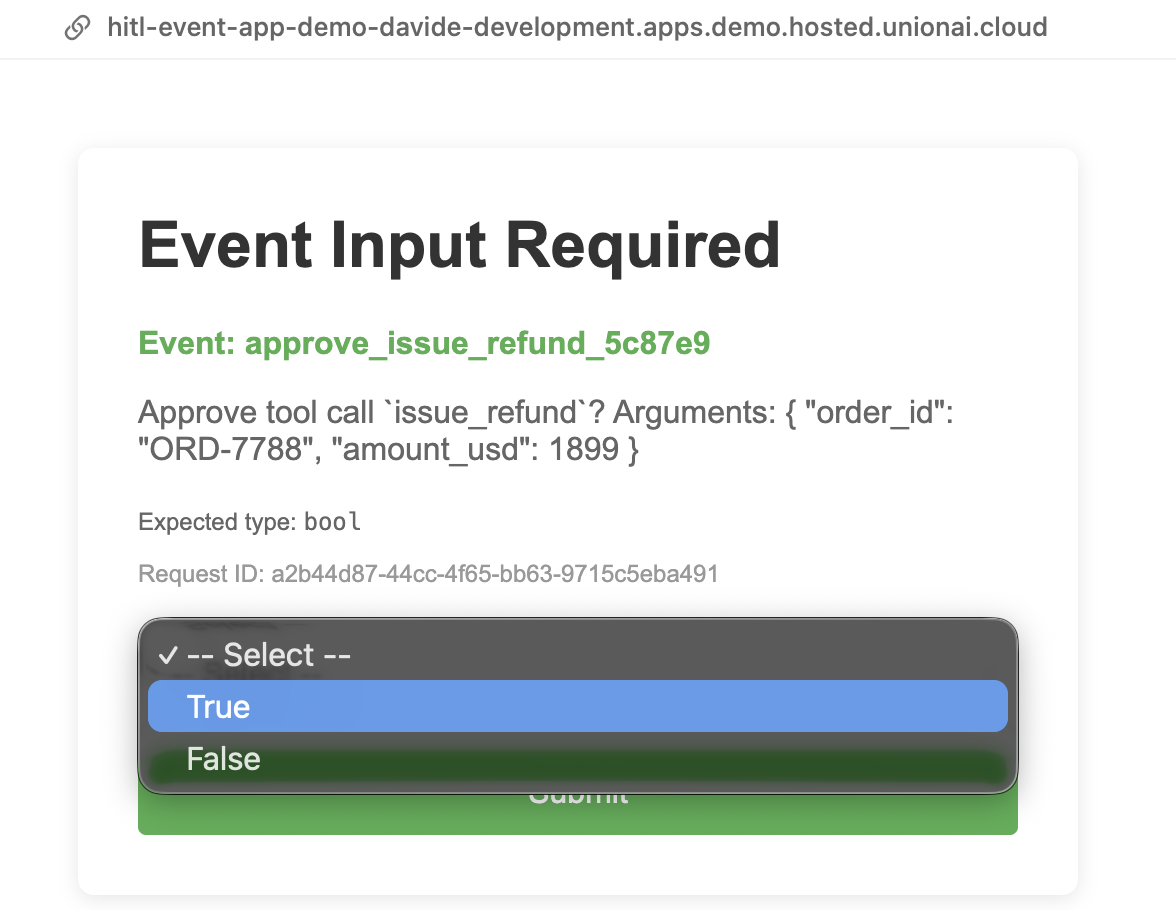

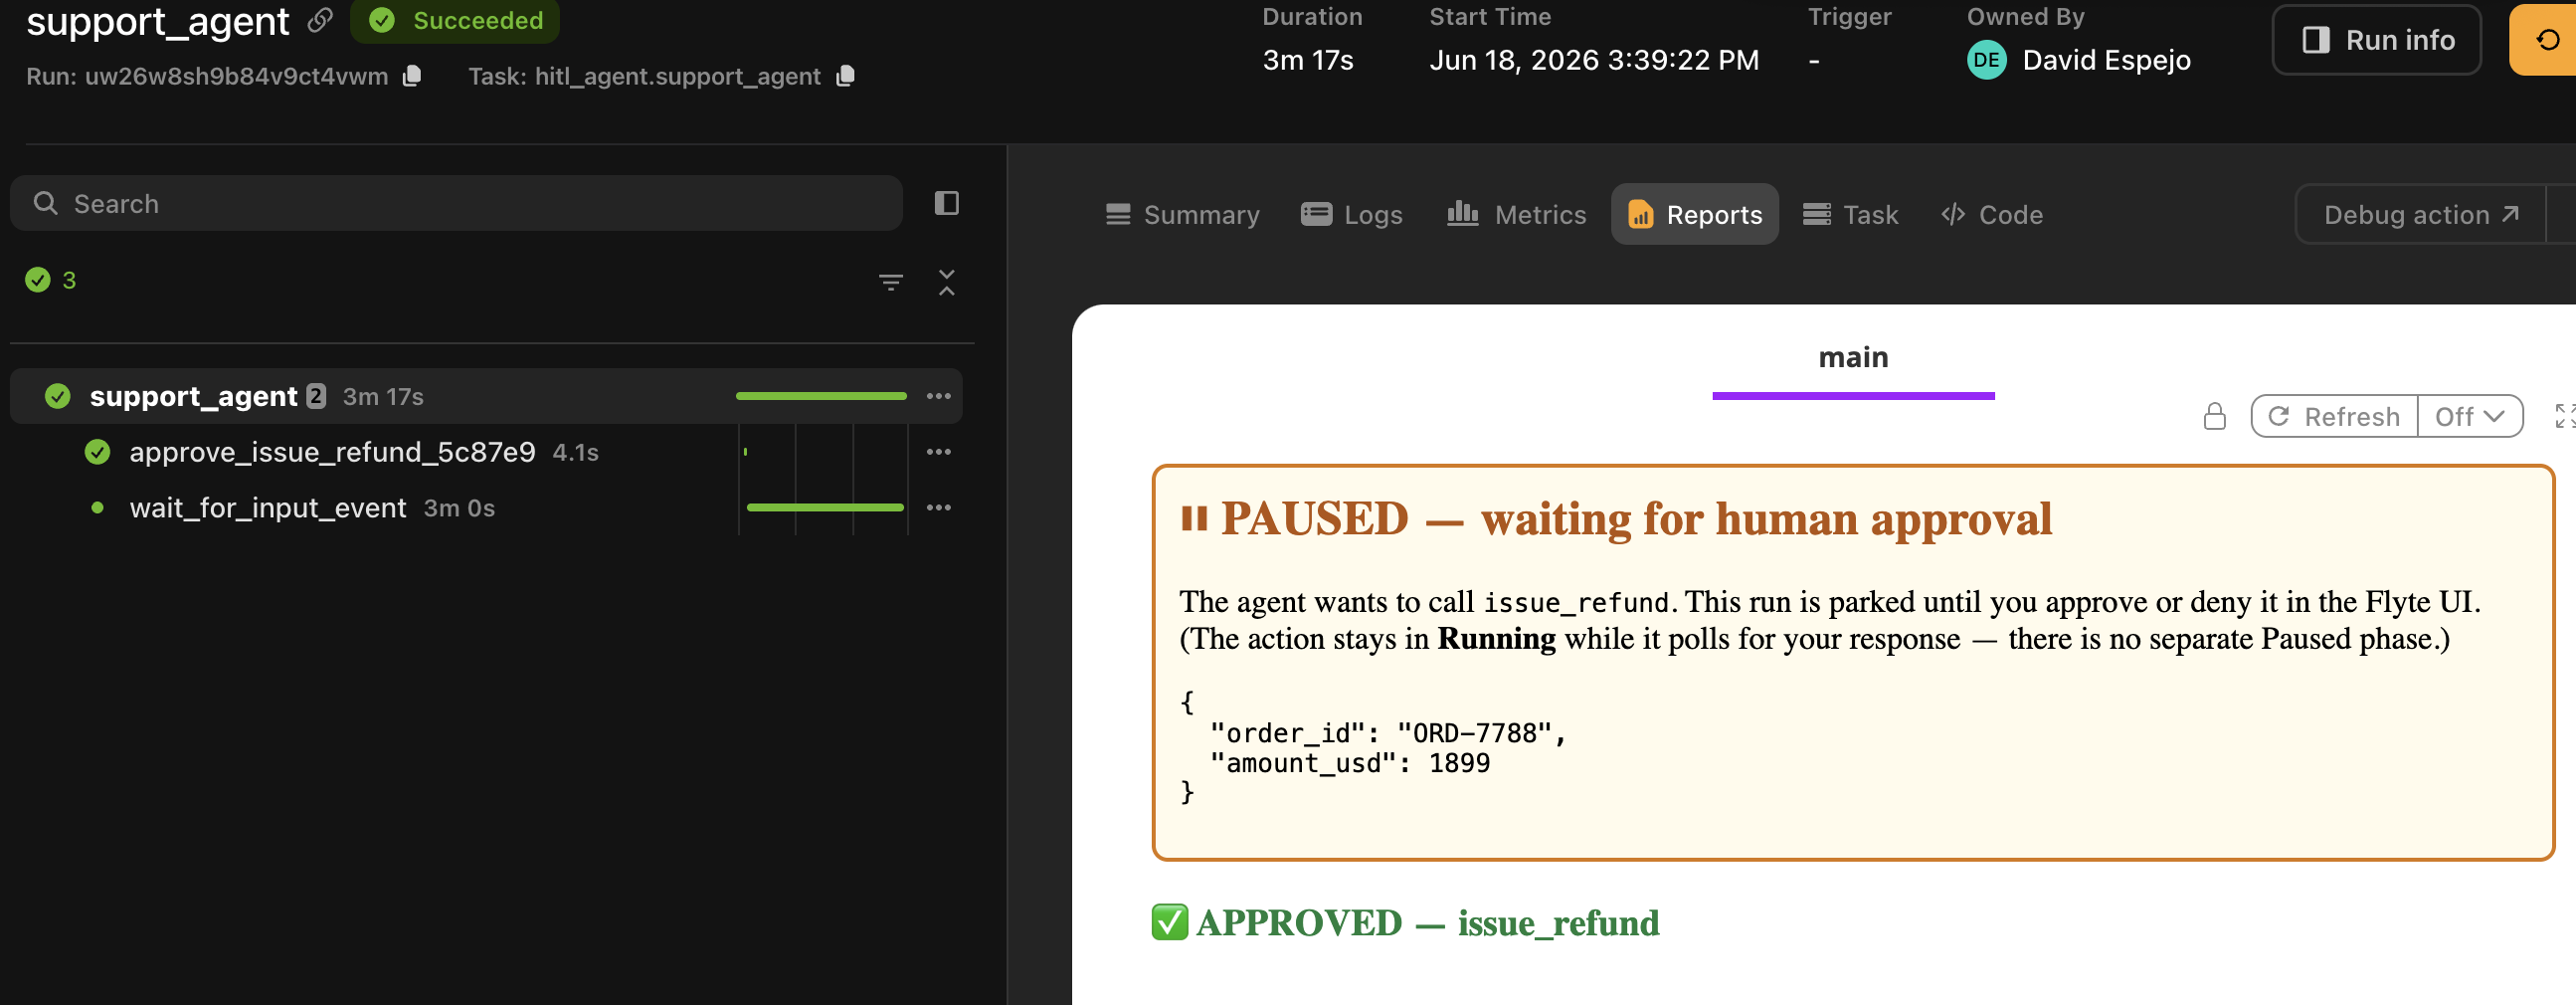